In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv("./Train.csv")

print("Dataset Loaded Successfully")
print("Shape :", df.shape)
display(df.sample(5))

Dataset Loaded Successfully
Shape : (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
1647,1648,B,Flight,4,4,198,2,medium,M,64,3787,1
627,628,B,Ship,4,2,190,5,high,F,38,3022,1
9844,9845,C,Road,2,2,174,3,low,F,3,5348,0
2898,2899,D,Ship,4,2,180,3,low,M,22,1261,1
1944,1945,D,Ship,4,4,184,3,low,F,52,3128,1


In [3]:
def prepare_features(dataframe):
    temp_df = dataframe.copy()
    
    # Remove identifier
    if "ID" in temp_df.columns:
        temp_df.drop("ID", axis=1, inplace=True)
    
    target = "Reached.on.Time_Y.N"
    
    X_data = temp_df.drop(columns=[target])
    y_data = temp_df[target]
    
    return X_data, y_data

X, y = prepare_features(df)

print("Feature Columns:", X.columns.tolist())

Feature Columns: ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']


In [4]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
Categorical Columns: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


In [5]:
# Numerical Pipeline: Fill missing values with median -> Scale data
numeric_pipe = Pipeline([
    ("median_fill", SimpleImputer(strategy="median")),
    ("scale_values", StandardScaler())
])

# Categorical Pipeline: Fill missing values with mode -> One-Hot Encode
categorical_pipe = Pipeline([
    ("freq_fill", SimpleImputer(strategy="most_frequent")),
    ("encode_cat", OneHotEncoder(handle_unknown="ignore"))
])

## 6. Execute Pipeline

In [7]:
X_processed = shipment_preprocessor.fit_transform(X)

print("Transformed Feature Shape:", X_processed.shape)

Transformed Feature Shape: (10999, 19)


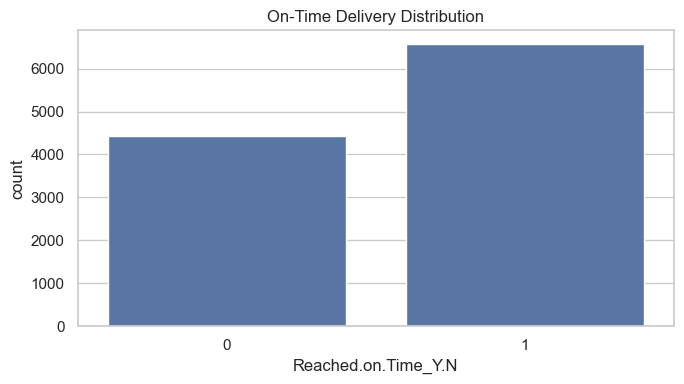

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(x=y)
plt.title("On-Time Delivery Distribution")
plt.tight_layout()
plt.show()

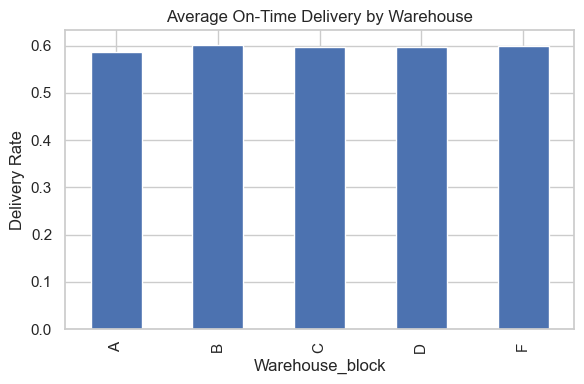

In [9]:
warehouse_summary = df.groupby("Warehouse_block")["Reached.on.Time_Y.N"].mean()

warehouse_summary.plot(kind="bar", figsize=(6, 4))
plt.title("Average On-Time Delivery by Warehouse")
plt.ylabel("Delivery Rate")
plt.tight_layout()
plt.show()